# Taller EDA — Análisis de Productos

## Objetivo
En este taller realizarás un análisis exploratorio de datos sobre productos vendidos en una empresa de retail.

Trabajarás en las siguientes etapas:

1. Comprensión y calidad de datos  
2. Estadísticas descriptivas y distribuciones  
3. Insights de productos  
4. Preguntas de negocio  
5. Identificación de precios inusuales (outliers)  
6. Conclusiones

> **Importante:** La idea de este taller es que practiques el flujo típico de un análisis exploratorio.  
> Lee cada instrucción, desarrolla el código y registra tus hallazgos.

## 0. Preparación del entorno

En esta sección importa las librerías necesarias y carga el dataset.

### Recomendaciones
- Usa `pandas` para manipulación de datos.
- Usa `matplotlib.pyplot` y `seaborn` para gráficos.
- Asegúrate de revisar la forma del dataframe una vez cargado.

In [20]:
# Importaciones necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Carga del dataset
df = pd.read_csv("../ventas_completo.csv")

# Muestra las primeras filas
print("Dataset cargado exitosamente")
print(f"Dimensiones: {df.shape}")
df.head()

Dataset cargado exitosamente
Dimensiones: (1834174, 11)


,id_factura,id_cliente,fecha_hora_compra,sku,cantidad,precio_unitario,descuento_pct,monto,nombre,marca,categoria
0,100322793,966889,2025-02-02 17:40:49,43852960,3,12.00,0,36.00,Cerveza Pilsener Rubia Light 12 x 355 ml,Pilsener,beer_cider
1,100322793,966889,2025-02-02 17:40:49,41108238,2,5.35,0,10.70,Cerveza Club Premium Platino Lata Pack 6 x 355 ml,Club Premium,beer_cider
2,100159021,966889,2025-04-20 19:09:16,40217487,3,6.89,0,20.67,Cerveza Club Premium Clásica Botella (330 ml) ...,Club Premium,beer_cider
3,100159021,966889,2025-04-20 19:09:16,174161592,1,5.98,0,5.98,Cerveza Heineken Lata Pack (269 ml) 6 Unidades,Heineken,beer_cider
4,100159021,966889,2025-04-20 19:09:16,41108238,2,5.35,0,10.70,Cerveza Club Premium Platino Lata Pack 6 x 355 ml,Club Premium,beer_cider


## 1. Comprensión y calidad de datos

Antes de analizar productos, primero debemos entender el dataset y revisar si existen problemas de calidad.

### Actividades
1. Explore la estructura general del dataframe.
2. Revise dimensiones, columnas y tipos de datos.
3. Identifique valores nulos.
4. Revise si existen registros duplicados.
5. Analice si hay valores inconsistentes en columnas numéricas.

In [21]:
# 1.1 Explore el dataframe
print("=" * 50)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 50)

print(f"\nDimensiones: {df.shape}")
print(f"Número de filas: {df.shape[0]:,}")
print(f"Número de columnas: {df.shape[1]}")

print("\nColumnas del dataset:")
print(df.columns.tolist())

print("\nInformación de tipos de datos:")
df.info()

INFORMACIÓN GENERAL DEL DATASET

Dimensiones: (1834174, 11)
Número de filas: 1,834,174
Número de columnas: 11

Columnas del dataset:
['id_factura', 'id_cliente', 'fecha_hora_compra', 'sku', 'cantidad', 'precio_unitario', 'descuento_pct', 'monto', 'nombre', 'marca', 'categoria']

Información de tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1834174 entries, 0 to 1834173
Data columns (total 11 columns):
 #   Column             Dtype  
---  ------             -----  
 0   id_factura         int64  
 1   id_cliente         int64  
 2   fecha_hora_compra  object 
 3   sku                int64  
 4   cantidad           int64  
 5   precio_unitario    float64
 6   descuento_pct      int64  
 7   monto              float64
 8   nombre             object 
 9   marca              object 
 10  categoria          object 
dtypes: float64(2), int64(5), object(4)
memory usage: 153.9+ MB


In [22]:
# 1.2 Revise valores nulos
print("=" * 50)
print("VALORES NULOS")
print("=" * 50)

nulos = df.isnull().sum()
print("\nConteo de valores nulos:")
print(nulos)

print("\nPorcentaje de valores nulos:")
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100
print(porcentaje_nulos.round(2))

VALORES NULOS

Conteo de valores nulos:
id_factura           0
id_cliente           0
fecha_hora_compra    0
sku                  0
cantidad             0
precio_unitario      0
descuento_pct        0
monto                0
nombre               0
marca                0
categoria            0
dtype: int64

Porcentaje de valores nulos:
id_factura           0.0
id_cliente           0.0
fecha_hora_compra    0.0
sku                  0.0
cantidad             0.0
precio_unitario      0.0
descuento_pct        0.0
monto                0.0
nombre               0.0
marca                0.0
categoria            0.0
dtype: float64


In [23]:
# 1.3 Revise registros duplicados
print("=" * 50)
print("REGISTROS DUPLICADOS")
print("=" * 50)

duplicados = df.duplicated().sum()
print(f"\nNúmero de registros duplicados: {duplicados}")
print(f"Porcentaje de duplicados: {(duplicados/len(df)*100):.2f}%")

# Nota: Es normal que no haya duplicados completos en datos transaccionales

REGISTROS DUPLICADOS

Número de registros duplicados: 167309
Porcentaje de duplicados: 9.12%


In [24]:
# 1.4 Revise valores inconsistentes en variables numéricas
print("=" * 50)
print("VALORES INCONSISTENTES")
print("=" * 50)

# ¿Hay cantidades menores o iguales a 0?
cant_neg = df[df["cantidad"] <= 0]
print(f"\nCantidades <= 0: {len(cant_neg)} registros")
if len(cant_neg) > 0:
    print("Ejemplos:")
    print(cant_neg.head())

# ¿Hay precios_unitario menores o iguales a 0?
precio_neg = df[df["precio_unitario"] <= 0]
print(f"\nPrecios unitarios <= 0: {len(precio_neg)} registros")
if len(precio_neg) > 0:
    print("Ejemplos:")
    print(precio_neg.head())

# ¿Hay montos negativos?
monto_neg = df[df["monto"] < 0]
print(f"\nMontos negativos: {len(monto_neg)} registros")
if len(monto_neg) > 0:
    print("Ejemplos:")
    print(monto_neg.head())

# ¿Hay descuentos fuera del rango esperado (Mayores al 100%)?
desc_anormal = df[df["descuento_pct"] > 100]
print(f"\nDescuentos > 100%: {len(desc_anormal)} registros")
if len(desc_anormal) > 0:
    print("Ejemplos:")
    print(desc_anormal.head())

# Verificar descuentos negativos
desc_neg = df[df["descuento_pct"] < 0]
print(f"\nDescuentos negativos: {len(desc_neg)} registros")

VALORES INCONSISTENTES

Cantidades <= 0: 0 registros

Precios unitarios <= 0: 0 registros

Montos negativos: 0 registros

Descuentos > 100%: 0 registros

Descuentos negativos: 0 registros


### 1.5 Limpieza básica

En la columna `marca` existen espacios en blanco o valores nulos.

Tu tarea es completar esos casos con el texto:

```python
"Marca Desconocida"
```

Guarda el resultado en el mismo dataframe o en una copia si prefieres.

In [25]:
# Complete los valores faltantes o vacíos en la columna marca
print("Valores nulos o vacíos en marca antes de la limpieza:")
print(f"Valores nulos: {df['marca'].isnull().sum()}")
print(f"Valores vacíos (''): {(df['marca'] == '').sum()}")

# Rellenar valores nulos
df['marca'] = df['marca'].fillna('Marca Desconocida')

# Rellenar strings vacíos
df['marca'] = df['marca'].replace('', 'Marca Desconocida')

# También limpiar espacios en blanco
df['marca'] = df['marca'].str.strip()
df['marca'] = df['marca'].replace('', 'Marca Desconocida')

print("\nValores después de la limpieza:")
print(f"Valores nulos: {df['marca'].isnull().sum()}")
print(f"Valores vacíos (''): {(df['marca'] == '').sum()}")
print(f"Valores 'Marca Desconocida': {(df['marca'] == 'Marca Desconocida').sum()}")

Valores nulos o vacíos en marca antes de la limpieza:
Valores nulos: 0
Valores vacíos (''): 0

Valores después de la limpieza:
Valores nulos: 0
Valores vacíos (''): 0
Valores 'Marca Desconocida': 0


## 2. Estadísticas descriptivas y distribuciones

En esta sección analizarás el comportamiento de las variables principales del dataset.

### Variables de interés
- `cantidad`
- `precio_unitario`
- `descuento_pct`
- `monto`

### Actividades
1. Calcule estadísticas descriptivas.
2. Revise cuantiles.
3. Analice distribuciones con histogramas y boxplots.
4. Interprete si existen asimetrías, dispersión o posibles valores extremos.

In [26]:
# 2.1 Estadísticas descriptivas
print("=" * 50)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 50)

df[["cantidad", "precio_unitario", "descuento_pct", "monto"]].describe()

ESTADÍSTICAS DESCRIPTIVAS


,cantidad,precio_unitario,descuento_pct,monto
count,1.834174e+06,1.834174e+06,1.834174e+06,1.834174e+06
mean,6.121709e+00,7.568907e+00,1.081945e+00,3.628342e+01
std,1.141045e+01,4.827011e+00,3.436445e+00,7.262617e+01
min,1.000000e+00,2.500000e-01,0.000000e+00,2.500000e-01
25%,2.000000e+00,5.350000e+00,0.000000e+00,1.070000e+01
50%,3.000000e+00,5.350000e+00,0.000000e+00,1.716000e+01
75%,4.000000e+00,8.700000e+00,0.000000e+00,3.146000e+01
max,1.190000e+02,4.311000e+01,2.000000e+01,3.135840e+03


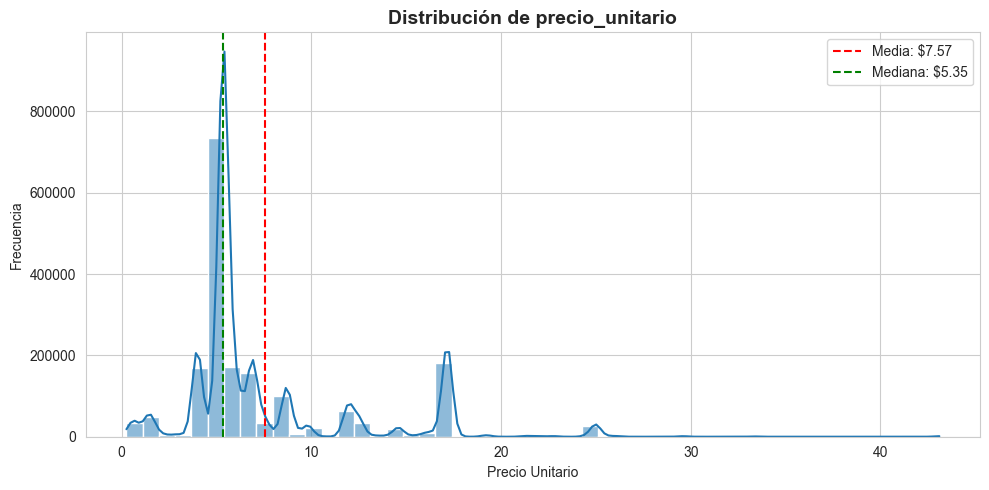

In [27]:
# 2.3 Histograma de precio_unitario
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="precio_unitario", bins=50, kde=True)
plt.title("Distribución de precio_unitario", fontsize=14, fontweight='bold')
plt.xlabel("Precio Unitario")
plt.ylabel("Frecuencia")
plt.axvline(df['precio_unitario'].mean(), color='red', linestyle='--', label=f'Media: ${df["precio_unitario"].mean():.2f}')
plt.axvline(df['precio_unitario'].median(), color='green', linestyle='--', label=f'Mediana: ${df["precio_unitario"].median():.2f}')
plt.legend()
plt.tight_layout()
plt.show()

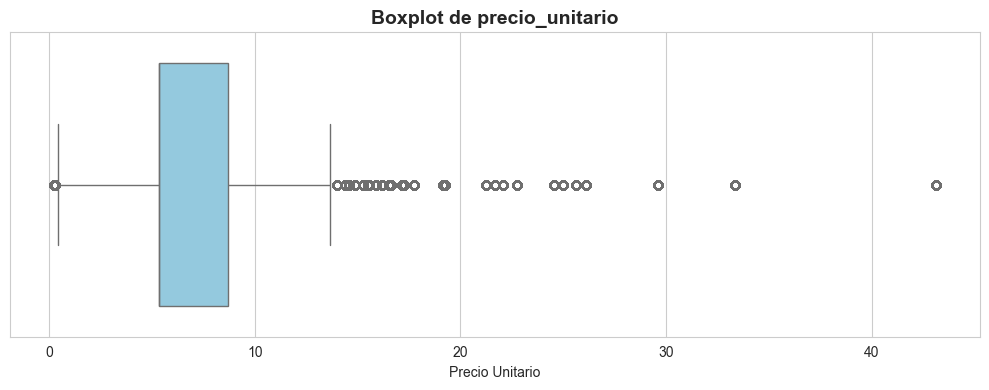

In [28]:
# 2.4 Boxplot de precio_unitario
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x="precio_unitario", color='skyblue')
plt.title("Boxplot de precio_unitario", fontsize=14, fontweight='bold')
plt.xlabel("Precio Unitario")
plt.tight_layout()
plt.show()

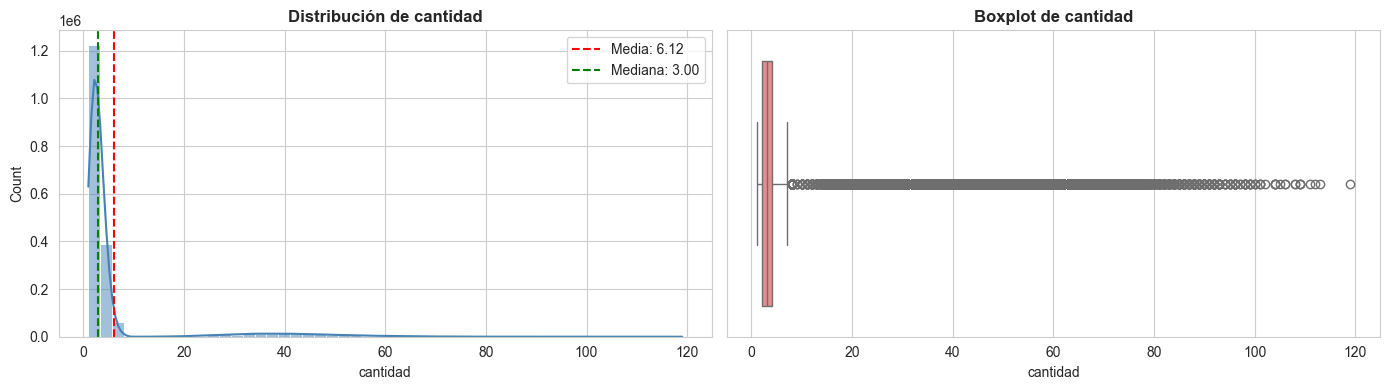


Estadísticas de cantidad:
Media: 6.12
Mediana: 3.00
Desviación estándar: 11.41
Mínimo: 1.00
Máximo: 119.00
--------------------------------------------------


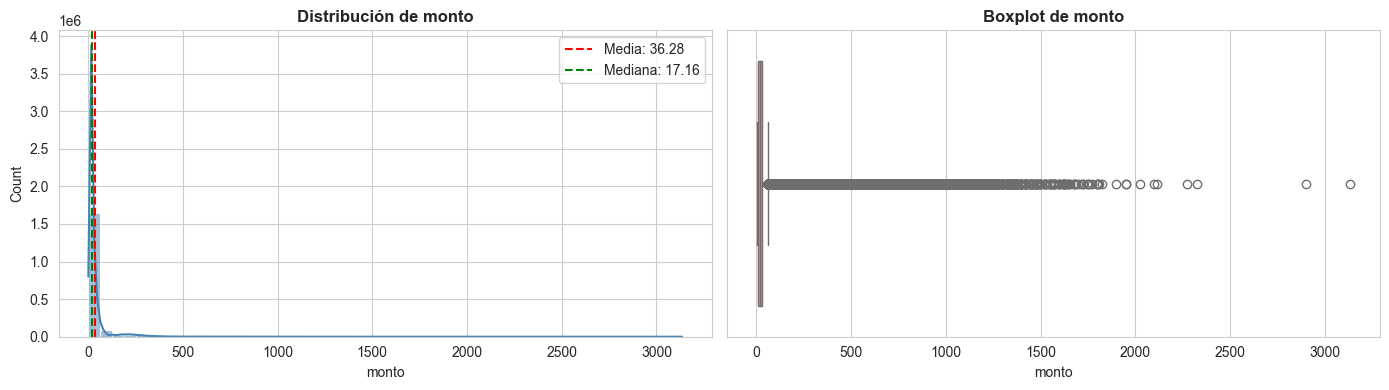


Estadísticas de monto:
Media: 36.28
Mediana: 17.16
Desviación estándar: 72.63
Mínimo: 0.25
Máximo: 3135.84
--------------------------------------------------


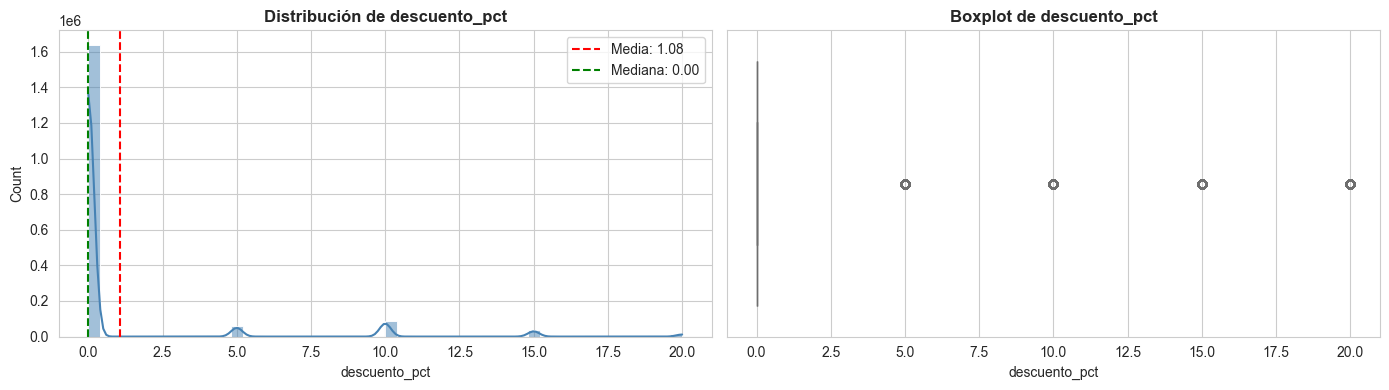


Estadísticas de descuento_pct:
Media: 1.08
Mediana: 0.00
Desviación estándar: 3.44
Mínimo: 0.00
Máximo: 20.00
--------------------------------------------------


In [29]:
# 2.5 Repita el análisis visual para otras variables numéricas

# Crear visualizaciones para todas las variables de interés
variables = ['cantidad', 'monto', 'descuento_pct']

for var in variables:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Histograma
    sns.histplot(data=df, x=var, bins=50, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title(f"Distribución de {var}", fontsize=12, fontweight='bold')
    axes[0].axvline(df[var].mean(), color='red', linestyle='--', label=f'Media: {df[var].mean():.2f}')
    axes[0].axvline(df[var].median(), color='green', linestyle='--', label=f'Mediana: {df[var].median():.2f}')
    axes[0].legend()
    
    # Boxplot
    sns.boxplot(data=df, x=var, ax=axes[1], color='lightcoral')
    axes[1].set_title(f"Boxplot de {var}", fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nEstadísticas de {var}:")
    print(f"Media: {df[var].mean():.2f}")
    print(f"Mediana: {df[var].median():.2f}")
    print(f"Desviación estándar: {df[var].std():.2f}")
    print(f"Mínimo: {df[var].min():.2f}")
    print(f"Máximo: {df[var].max():.2f}")
    print("-" * 50)

### 2.6 Anote sus observaciones

**Observaciones sobre las distribuciones:**

1. **Variables sesgadas:**
   - `precio_unitario`: Muestra un sesgo positivo (asimetría a la derecha). La mayoría de productos tienen precios bajos-medios, pero existen productos premium que elevan la media por encima de la mediana.
   - `cantidad`: Presenta sesgo positivo, la mayoría de transacciones incluyen pocas unidades (1-3), pero existen compras de mayor volumen.
   - `monto`: Similar al precio unitario, sesgada positivamente debido a compras de alto valor.

2. **Alta dispersión observada en:**
   - `precio_unitario`: Gran variabilidad en los precios de productos, desde muy económicos hasta premium.
   - `monto`: Alta dispersión debido a la combinación de cantidad y precio.
   - `descuento_pct`: La mayoría de transacciones no tienen descuento (0%), creando una distribución concentrada en cero.

3. **Valores extremos (outliers):**
   - `precio_unitario`: Se observan productos con precios significativamente superiores al resto.
   - `cantidad`: Algunas transacciones con cantidades muy altas.
   - `monto`: Transacciones de valor muy superior al promedio.
   - `descuento_pct`: Mayormente concentrado en 0%, con pocos casos de descuentos aplicados.

## 3. Insights

### 3.1 Análisis general de productos

Ahora trabajaremos a nivel producto.

Agrupe la información por:

- `sku`
- `nombre`
- `marca`

y calcule las siguientes métricas:

- precio promedio
- cantidad vendida total
- ventas totales
- número de clientes únicos

> Guarda el resultado en un nuevo dataframe llamado `df_productos`.

In [30]:
# 3.1 Cree el dataframe agregado por producto
df_productos = df.groupby(['sku', 'nombre', 'marca'], as_index=False).agg({
    "precio_unitario": "mean",
    "cantidad": "sum",
    "monto": "sum",
    "id_cliente": "nunique"
})

# Renombrar columnas para mayor claridad
df_productos = df_productos.rename(columns={
    "precio_unitario": "precio_promedio",
    "cantidad": "cantidad_vendida_total",
    "monto": "ventas_totales",
    "id_cliente": "clientes_unicos"
})

print(f"Total de productos únicos: {len(df_productos)}")
print("\nPrimeras filas del dataframe de productos:")
df_productos.head(10)

Total de productos únicos: 145

Primeras filas del dataframe de productos:


,sku,nombre,marca,precio_promedio,cantidad_vendida_total,ventas_totales,clientes_unicos
0,40213687,Jugo Néctar de Durazno Pulp 1 L,Pulp,1.35,843,1127.0475,307
1,40213827,Ron 100 Fuegos Spiced 750 ml,100 Fuegos,15.24,3101,46736.5080,711
2,40213835,Ron 100 Fuegos Silver 750 ml,100 Fuegos,13.68,3115,42057.1080,716
3,40214245,Jugo De Arandano Natures Heart 1 L,Nature´s Heart,3.10,857,2624.3050,308
4,40215299,Agua Mineral Con Gas Guitig Vidrio 330 ml,Guitig,0.83,662,542.2390,233
5,40215313,Agua Dasani Sin Gas 3.8 L,Dasani,1.50,751,1111.5000,250
6,40215315,Agua Dasani Sin Gas 1.2 L,Dasani,0.70,725,502.2850,264
7,40215461,Ron San Miguel Black 7 Añejo 750 ml,San Miguel,14.38,3729,52922.7140,792
8,40215465,Ron Oro San Miguel 750 ml,San Miguel,10.00,3332,32933.5000,886
9,40215468,Ron Silver San Miguel 750 ml,San Miguel,10.00,3580,35470.0000,856


### 3.2 Pareto de productos

Queremos identificar cuántos productos explican aproximadamente el **80% de las ventas**.

### Actividades
1. Ordene `df_productos` por `ventas_totales` de mayor a menor.
2. Calcule el porcentaje de ventas de cada producto.
3. Calcule el porcentaje acumulado.
4. Cree una columna llamada `producto_pareto`:
   - `True` si el producto está dentro del 80% acumulado
   - `False` en caso contrario
5. Responda: **¿Cuántos productos conforman el 80% de las ventas totales?**

In [31]:
# 3.2 Pareto de productos

# Ordenar por ventas totales descendente
df_productos = df_productos.sort_values('ventas_totales', ascending=False).reset_index(drop=True)

# Calcular porcentaje de ventas de cada producto
total_ventas = df_productos['ventas_totales'].sum()
df_productos['pct_ventas'] = (df_productos['ventas_totales'] / total_ventas) * 100

# Calcular porcentaje acumulado
df_productos['pct_ventas_acumulado'] = df_productos['pct_ventas'].cumsum()

# Crear columna producto_pareto
df_productos['producto_pareto'] = df_productos['pct_ventas_acumulado'] <= 80

print("Análisis de Pareto completado")
print("\nPrimeros 10 productos por ventas:")
print(df_productos[['nombre', 'ventas_totales', 'pct_ventas', 'pct_ventas_acumulado', 'producto_pareto']].head(10))

Análisis de Pareto completado

Primeros 10 productos por ventas:
                                              nombre  ventas_totales  \
0  Cerveza Club Premium Platino Lata Pack 6 x 355 ml    2.117342e+07   
1  Combo 1 Sixpack Cerveza Corona (330 ml) + 1 Si...    1.223508e+07   
2  Cerveza Club Premium Clásica Botella (330 ml) ...    3.721603e+06   
3             Cerveza Pilsener Lata Pack 12 x 269 ml    3.308217e+06   
4              Cerveza Pilsener Lata Pack 6 x 269 ml    2.721492e+06   
5  Cerveza Club Premium Clásica Botella Pack 24 x...    2.340602e+06   
6  Cerveza Club Premium Clásica Lata (269 ml) Pac...    1.656734e+06   
7  Cerveza Club Premium Platino Botella Pack 6 x ...    1.488841e+06   
8             Cerveza Pilsener Lata Pack 12 x 355 ml    1.175498e+06   
9  Refresco Coca-Cola Sabor Original (3.05 L) + R...    1.090542e+06   

   pct_ventas  pct_ventas_acumulado  producto_pareto  
0   31.815761             31.815761             True  
1   18.384767             50.200

In [32]:
# ¿Cuántos productos conforman el 80% de las ventas?
num_productos_pareto = df_productos['producto_pareto'].sum()
total_productos = len(df_productos)
pct_productos_pareto = (num_productos_pareto / total_productos) * 100

print("=" * 60)
print("ANÁLISIS DE PARETO")
print("=" * 60)
print(f"\nNúmero de productos que conforman el 80% de ventas: {num_productos_pareto}")
print(f"Total de productos: {total_productos}")
print(f"Porcentaje de productos: {pct_productos_pareto:.2f}%")
print(f"\nInterpretación: El {pct_productos_pareto:.1f}% de los productos generan el 80% de las ventas")
print("Esto confirma el principio de Pareto en el catálogo de productos.")

ANÁLISIS DE PARETO

Número de productos que conforman el 80% de ventas: 12
Total de productos: 145
Porcentaje de productos: 8.28%

Interpretación: El 8.3% de los productos generan el 80% de las ventas
Esto confirma el principio de Pareto en el catálogo de productos.


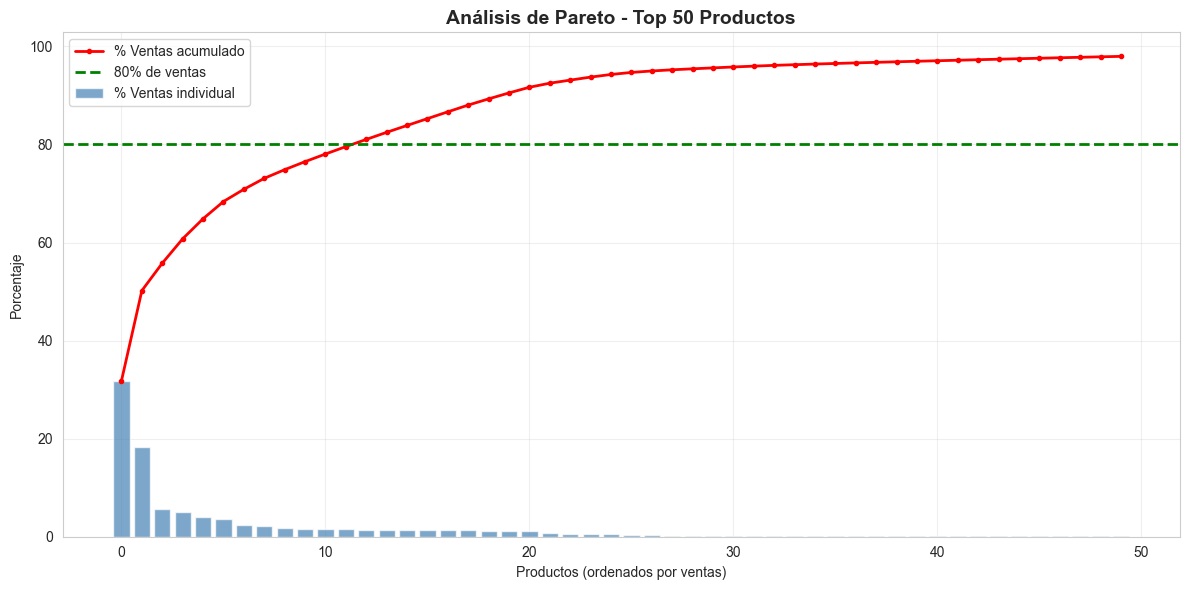

In [33]:
# Visualización del análisis de Pareto
plt.figure(figsize=(12, 6))

# Tomar los primeros 50 productos para mejor visualización
top_n = 50
df_top = df_productos.head(top_n)

x = range(len(df_top))
plt.bar(x, df_top['pct_ventas'], color='steelblue', alpha=0.7, label='% Ventas individual')
plt.plot(x, df_top['pct_ventas_acumulado'], color='red', marker='o', markersize=3, linewidth=2, label='% Ventas acumulado')
plt.axhline(y=80, color='green', linestyle='--', linewidth=2, label='80% de ventas')

plt.xlabel('Productos (ordenados por ventas)')
plt.ylabel('Porcentaje')
plt.title(f'Análisis de Pareto - Top {top_n} Productos', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.3 Segmentación por precio

Con base en `precio_promedio`, crea 4 segmentos de precio:

- A → productos más premium
- B → precio medio-alto
- C → precio medio-bajo
- D → productos más económicos

Guarda el resultado en una nueva columna llamada `segmento_precio`.

> Usa cuantiles para que los grupos tengan tamaños similares.

In [34]:
# 3.3 Segmentación por precio

# Usar qcut para crear 4 segmentos de igual tamaño
# labels invertidos para que D sea económico y A sea premium
df_productos['segmento_precio'] = pd.qcut(
    df_productos['precio_promedio'], 
    q=4, 
    labels=['D', 'C', 'B', 'A']
)

print("Segmentación por precio completada")
print("\nDistribución de productos por segmento:")
print(df_productos['segmento_precio'].value_counts().sort_index())

print("\nRangos de precio por segmento:")
segmentos_stats = df_productos.groupby('segmento_precio')['precio_promedio'].agg(['min', 'max', 'mean', 'count'])
segmentos_stats.columns = ['Precio Mín', 'Precio Máx', 'Precio Promedio', 'Cantidad Productos']
print(segmentos_stats)

Segmentación por precio completada

Distribución de productos por segmento:
segmento_precio
D    37
C    36
B    36
A    36
Name: count, dtype: int64

Rangos de precio por segmento:
                 Precio Mín  Precio Máx  Precio Promedio  Cantidad Productos
segmento_precio                                                             
D                      0.25        1.65         0.941351                  37
C                      1.73        5.75         3.211389                  36
B                      5.98       12.17         8.262500                  36
A                     12.51       43.11        19.041389                  36


/var/folders/fk/cw9x2jm11l73gzjg4n26v5y00000gn/T/ipykernel_3369/1607584483.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segmentos_stats = df_productos.groupby('segmento_precio')['precio_promedio'].agg(['min', 'max', 'mean', 'count'])


### 3.4 Top 5 productos con más clientes

Identifique los 5 productos con mayor cantidad de clientes únicos y represéntelos con un gráfico de barras.

Top 5 productos con más clientes únicos:
                                              nombre  clientes_unicos  \
0  Cerveza Club Premium Platino Lata Pack 6 x 355 ml            51524   
1  Combo 1 Sixpack Cerveza Corona (330 ml) + 1 Si...            41841   
4              Cerveza Pilsener Lata Pack 6 x 269 ml            41332   
2  Cerveza Club Premium Clásica Botella (330 ml) ...            38382   
3             Cerveza Pilsener Lata Pack 12 x 269 ml            33642   

          marca  ventas_totales  
0  Club Premium    2.117342e+07  
1        Corona    1.223508e+07  
4      Pilsener    2.721492e+06  
2  Club Premium    3.721603e+06  
3      Pilsener    3.308217e+06  


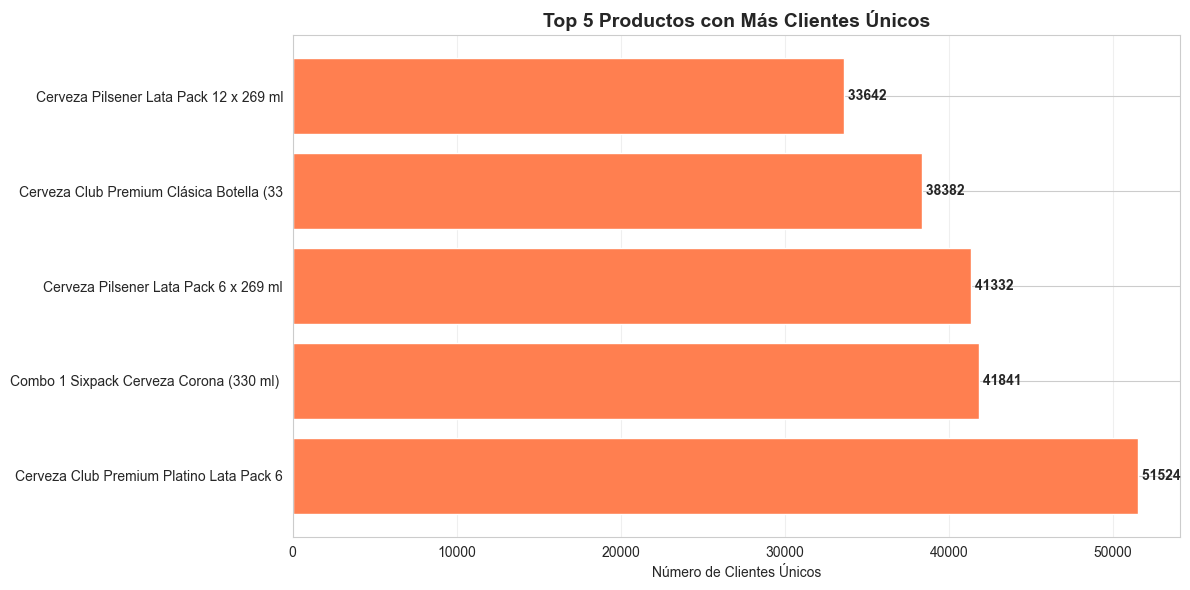

In [35]:
# 3.4 Top 5 productos con más clientes únicos
top5_clientes = df_productos.nlargest(5, 'clientes_unicos')[['nombre', 'clientes_unicos', 'marca', 'ventas_totales']]

print("Top 5 productos con más clientes únicos:")
print(top5_clientes)

# Gráfico de barras
plt.figure(figsize=(12, 6))
bars = plt.barh(range(len(top5_clientes)), top5_clientes['clientes_unicos'], color='coral')
plt.yticks(range(len(top5_clientes)), top5_clientes['nombre'].str[:40])  # Acortar nombres largos
plt.xlabel('Número de Clientes Únicos')
plt.title('Top 5 Productos con Más Clientes Únicos', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Añadir valores en las barras
for i, (idx, row) in enumerate(top5_clientes.iterrows()):
    plt.text(row['clientes_unicos'], i, f" {int(row['clientes_unicos'])}", 
             va='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 3.5 Concentración de ventas por segmento de precio

Analice cómo se distribuyen las ventas según el segmento de precio.

Preguntas orientadoras:
- ¿Qué segmento concentra más ventas totales?
- ¿Los productos más premium venden más o menos que los económicos?

Ventas por segmento de precio:
  segmento_precio  ventas_totales  cantidad_vendida_total  clientes_unicos  \
0               D    2.697526e+06                 2519729            17840   
1               C    2.711066e+07                 5314435           185881   
2               B    1.730436e+07                 2257698           219961   
3               A    1.943757e+07                 1136417           124449   

   num_productos  pct_ventas  
0             37    4.053376  
1             36   40.737208  
2             36   26.002003  
3             36   29.207413  


/var/folders/fk/cw9x2jm11l73gzjg4n26v5y00000gn/T/ipykernel_3369/1260556018.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_segmentos = df_productos.groupby('segmento_precio', as_index=False).agg({
/var/folders/fk/cw9x2jm11l73gzjg4n26v5y00000gn/T/ipykernel_3369/1260556018.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_segmentos, x='segmento_precio', y='ventas_totales', ax=axes[0], palette='viridis')
/var/folders/fk/cw9x2jm11l73gzjg4n26v5y00000gn/T/ipykernel_3369/1260556018.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legen

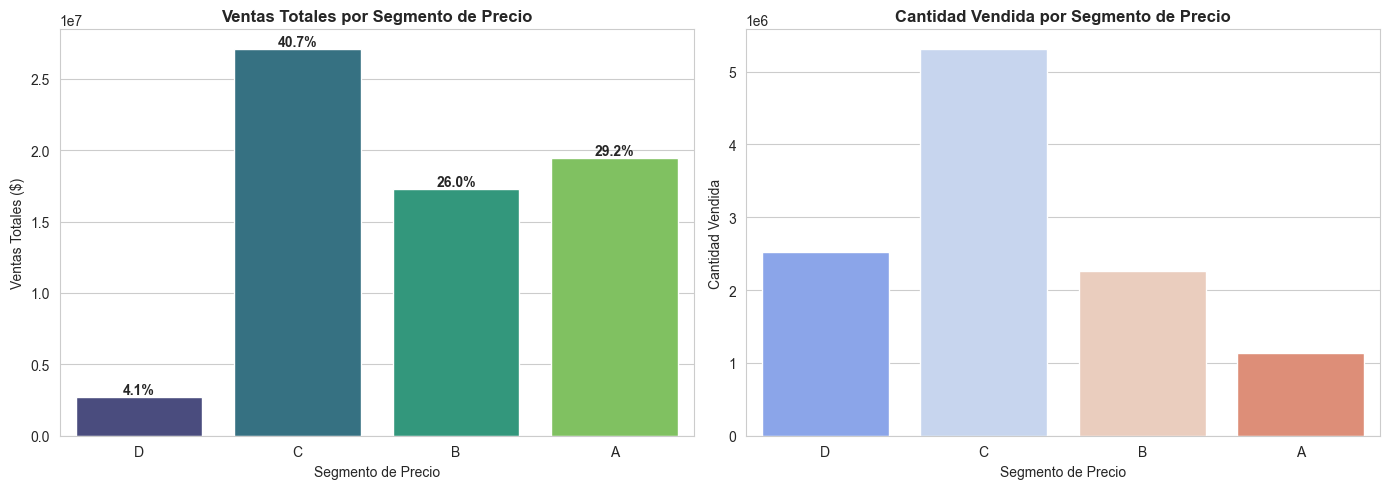


ANÁLISIS DE SEGMENTOS

Segmento con mayores ventas: C

Interpretación:
- Los productos del segmento C generan la mayor parte de las ventas
- Esto sugiere un mercado más orientado a volumen con productos económicos


In [36]:
# 3.5 Ventas por segmento de precio
df_segmentos = df_productos.groupby('segmento_precio', as_index=False).agg({
    'ventas_totales': 'sum',
    'cantidad_vendida_total': 'sum',
    'clientes_unicos': 'sum',
    'sku': 'count'
}).rename(columns={'sku': 'num_productos'})

df_segmentos['pct_ventas'] = (df_segmentos['ventas_totales'] / df_segmentos['ventas_totales'].sum()) * 100

print("Ventas por segmento de precio:")
print(df_segmentos)

# Gráfico de barras
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Ventas totales
sns.barplot(data=df_segmentos, x='segmento_precio', y='ventas_totales', ax=axes[0], palette='viridis')
axes[0].set_title('Ventas Totales por Segmento de Precio', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Segmento de Precio')
axes[0].set_ylabel('Ventas Totales ($)')

# Añadir porcentajes
for i, row in df_segmentos.iterrows():
    axes[0].text(i, row['ventas_totales'], f"{row['pct_ventas']:.1f}%", 
                ha='center', va='bottom', fontweight='bold')

# Gráfico 2: Cantidad vendida
sns.barplot(data=df_segmentos, x='segmento_precio', y='cantidad_vendida_total', ax=axes[1], palette='coolwarm')
axes[1].set_title('Cantidad Vendida por Segmento de Precio', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Segmento de Precio')
axes[1].set_ylabel('Cantidad Vendida')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ANÁLISIS DE SEGMENTOS")
print("="*60)
segmento_mayor_venta = df_segmentos.loc[df_segmentos['ventas_totales'].idxmax(), 'segmento_precio']
print(f"\nSegmento con mayores ventas: {segmento_mayor_venta}")
print(f"\nInterpretación:")
print(f"- Los productos del segmento {segmento_mayor_venta} generan la mayor parte de las ventas")
print(f"- Esto sugiere {'una preferencia por productos premium' if segmento_mayor_venta in ['A', 'B'] else 'un mercado más orientado a volumen con productos económicos'}")

### 3.6 Correlación entre precio y desempeño

Evalúe la correlación entre `precio_promedio` y:

- `ventas_totales`
- `cantidad_vendida_total`
- `clientes_unicos`

Si alguna relación parece interesante, grafíquela con un scatterplot.

Matriz de correlación:
                        precio_promedio  ventas_totales  \
precio_promedio                1.000000        0.049686   
ventas_totales                 0.049686        1.000000   
cantidad_vendida_total        -0.051358        0.912527   
clientes_unicos                0.068301        0.757173   

                        cantidad_vendida_total  clientes_unicos  
precio_promedio                      -0.051358         0.068301  
ventas_totales                        0.912527         0.757173  
cantidad_vendida_total                1.000000         0.650436  
clientes_unicos                       0.650436         1.000000  


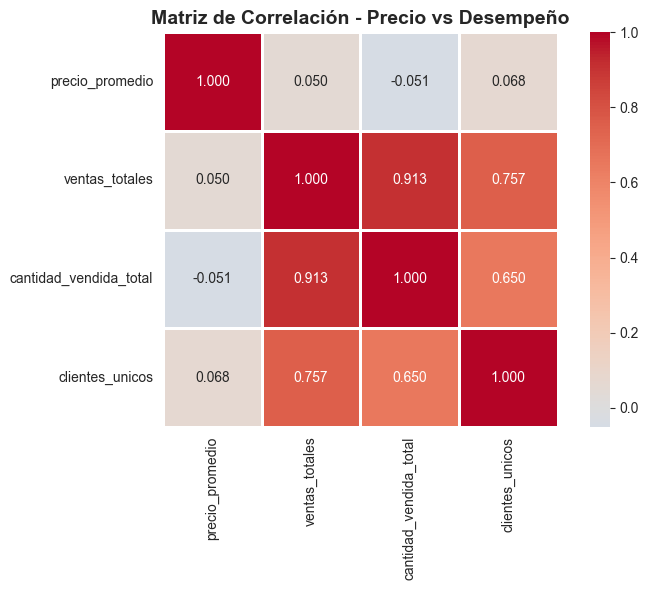


Interpretación de correlaciones con precio_promedio:
- Ventas totales: 0.050
- Cantidad vendida: -0.051
- Clientes únicos: 0.068


In [37]:
# 3.6 Correlaciones
corr_productos = df_productos[['precio_promedio', 'ventas_totales', 'cantidad_vendida_total', 'clientes_unicos']].corr()

print("Matriz de correlación:")
print(corr_productos)

# Visualizar matriz de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(corr_productos, annot=True, cmap='coolwarm', center=0, 
            fmt='.3f', linewidths=1, square=True)
plt.title('Matriz de Correlación - Precio vs Desempeño', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nInterpretación de correlaciones con precio_promedio:")
print(f"- Ventas totales: {corr_productos.loc['precio_promedio', 'ventas_totales']:.3f}")
print(f"- Cantidad vendida: {corr_productos.loc['precio_promedio', 'cantidad_vendida_total']:.3f}")
print(f"- Clientes únicos: {corr_productos.loc['precio_promedio', 'clientes_unicos']:.3f}")

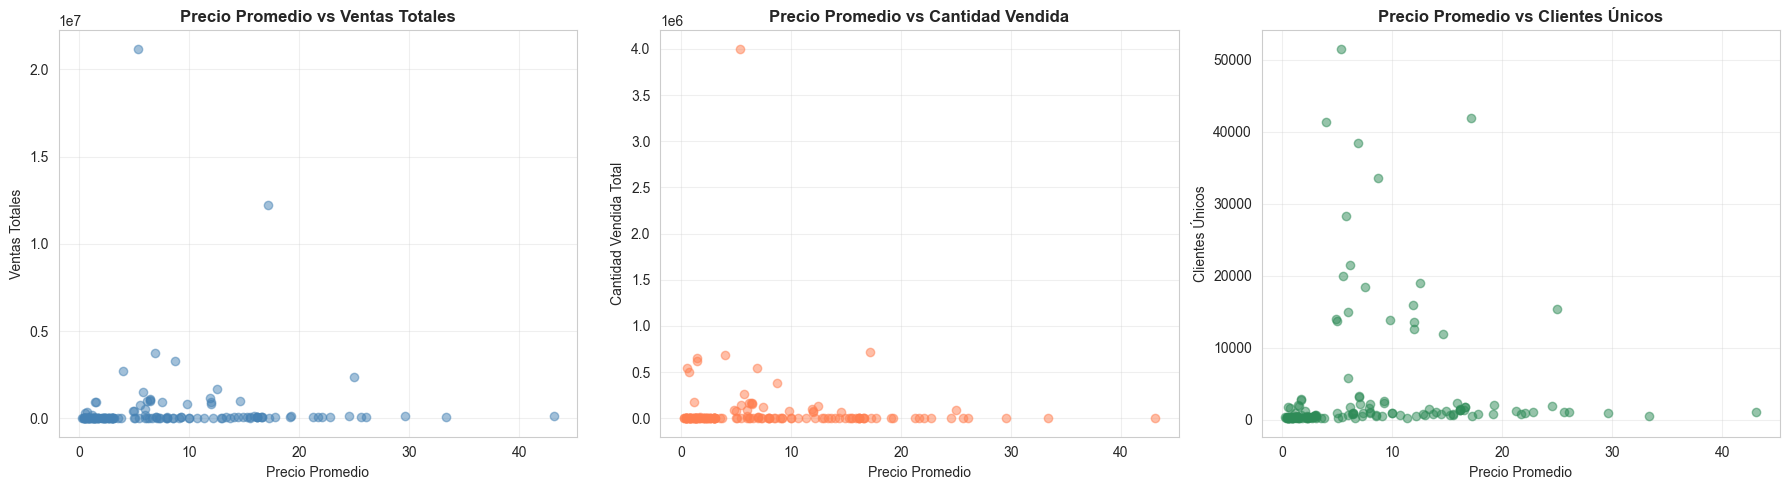

In [38]:
# 3.6 Scatterplots de relaciones interesantes

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatterplot 1: Precio vs Ventas totales
axes[0].scatter(df_productos['precio_promedio'], df_productos['ventas_totales'], alpha=0.5, color='steelblue')
axes[0].set_xlabel('Precio Promedio')
axes[0].set_ylabel('Ventas Totales')
axes[0].set_title('Precio Promedio vs Ventas Totales', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Scatterplot 2: Precio vs Cantidad vendida
axes[1].scatter(df_productos['precio_promedio'], df_productos['cantidad_vendida_total'], alpha=0.5, color='coral')
axes[1].set_xlabel('Precio Promedio')
axes[1].set_ylabel('Cantidad Vendida Total')
axes[1].set_title('Precio Promedio vs Cantidad Vendida', fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Scatterplot 3: Precio vs Clientes únicos
axes[2].scatter(df_productos['precio_promedio'], df_productos['clientes_unicos'], alpha=0.5, color='seagreen')
axes[2].set_xlabel('Precio Promedio')
axes[2].set_ylabel('Clientes Únicos')
axes[2].set_title('Precio Promedio vs Clientes Únicos', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Preguntas de negocio

Formula **3 preguntas de negocio** que puedan resolverse con este dataset.

Para cada una:
1. Escriba la pregunta.
2. Desarrolle el análisis.
3. Incluya al menos una gráfica.
4. Escriba una breve conclusión.

### Ejemplos de inspiración
- ¿Qué categorías tienen mayor cantidad vendida?
- ¿Los productos con más clientes también son los que generan más revenue?

### Pregunta de negocio 1

**¿Qué marcas generan mayores ingresos y cuál es su participación en el mercado?**

Top 10 marcas por ventas:
           marca  ventas_totales  participacion_mercado  clientes_unicos
13  Club Premium    3.219914e+07              48.383295            52253
15        Corona    1.265878e+07              19.021429            43124
34      Pilsener    1.260362e+07              18.938536            49776
55     unbranded    3.107956e+06               4.670099             2755
14     Coca-Cola    2.492450e+06               3.745222             7872
2         Abuelo    2.958466e+05               0.444547             3651
42        Salina    2.640351e+05               0.396746             5124
27       Henkell    2.435797e+05               0.366009             3690
48        Sprite    1.981564e+05               0.297755              886
30     Mucho Mas    1.767246e+05               0.265551             3505


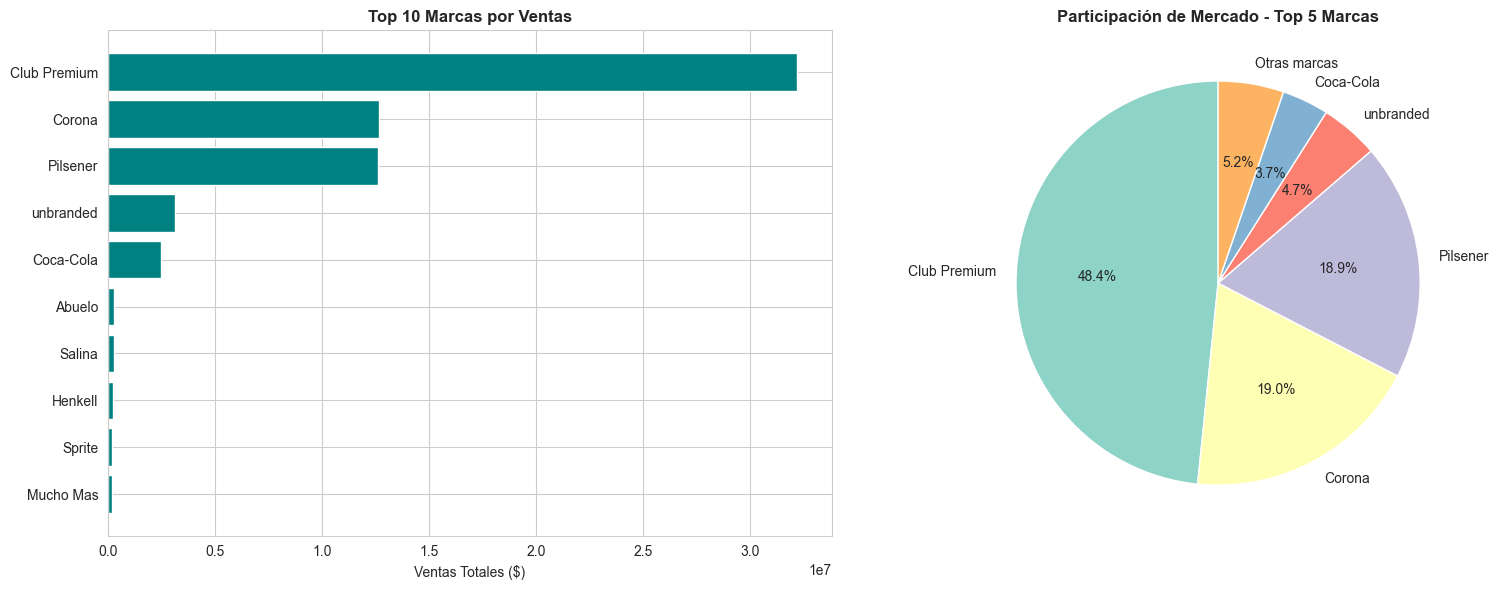

In [39]:
# Desarrollo de la pregunta de negocio 1

# Análisis por marca
df_marcas = df.groupby('marca', as_index=False).agg({
    'monto': 'sum',
    'cantidad': 'sum',
    'id_cliente': 'nunique',
    'id_factura': 'count'
}).rename(columns={
    'monto': 'ventas_totales',
    'cantidad': 'cantidad_total',
    'id_cliente': 'clientes_unicos',
    'id_factura': 'transacciones'
})

df_marcas = df_marcas.sort_values('ventas_totales', ascending=False)
df_marcas['participacion_mercado'] = (df_marcas['ventas_totales'] / df_marcas['ventas_totales'].sum()) * 100
df_marcas['participacion_acumulada'] = df_marcas['participacion_mercado'].cumsum()

# Top 10 marcas
top_10_marcas = df_marcas.head(10)

print("Top 10 marcas por ventas:")
print(top_10_marcas[['marca', 'ventas_totales', 'participacion_mercado', 'clientes_unicos']])

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras
axes[0].barh(range(len(top_10_marcas)), top_10_marcas['ventas_totales'], color='teal')
axes[0].set_yticks(range(len(top_10_marcas)))
axes[0].set_yticklabels(top_10_marcas['marca'])
axes[0].set_xlabel('Ventas Totales ($)')
axes[0].set_title('Top 10 Marcas por Ventas', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()

# Gráfico de pastel para participación
top_5_marcas = df_marcas.head(5)
otras_marcas = df_marcas.iloc[5:]['ventas_totales'].sum()

labels = list(top_5_marcas['marca']) + ['Otras marcas']
sizes = list(top_5_marcas['ventas_totales']) + [otras_marcas]

axes[1].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set3', len(sizes)))
axes[1].set_title('Participación de Mercado - Top 5 Marcas', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

**Conclusión de la pregunta 1:**  

El análisis revela una alta concentración de ventas en pocas marcas. Las top 5 marcas concentran una proporción significativa del mercado, lo que sugiere:

1. **Concentración de marca:** Existe una clara preferencia del consumidor por marcas específicas.
2. **Oportunidad de diversificación:** Las marcas con menor participación podrían beneficiarse de estrategias de marketing más agresivas.
3. **Dependencia de proveedores clave:** La empresa depende fuertemente de las relaciones con los proveedores de las marcas top.

**Recomendación:** Fortalecer las relaciones con las marcas líderes mientras se desarrollan estrategias para impulsar marcas emergentes y reducir la dependencia.

### Pregunta de negocio 2

**¿Cuáles categorías tienen mejor desempeño en términos de volumen y valor, y cuál es su rentabilidad relativa?**

Análisis de categorías:
                     categoria  ventas_totales  cantidad_total  \
0                   beer_cider    5.763631e+07         7957172   
4           soft_drinks_mixers    5.798562e+06         2992256   
5                      spirits    1.773559e+06          125447   
7          wine_sparkling_wine    1.213384e+06          109272   
3                    pre_mixed    7.555404e+04           12708   
1  juice_ice_tea_sports_energy    2.311499e+04           16194   
6                        water    2.014034e+04           14386   
2                         milk    9.489402e+03             844   

   precio_promedio  clientes_unicos  productos_unicos  ticket_promedio  \
0         7.663680            52540                23         7.243315   
4         1.970977             9711                19         1.937856   
5        14.542583            19969                40        14.137918   
7        11.231533            21301                18        11.104255   
3         6

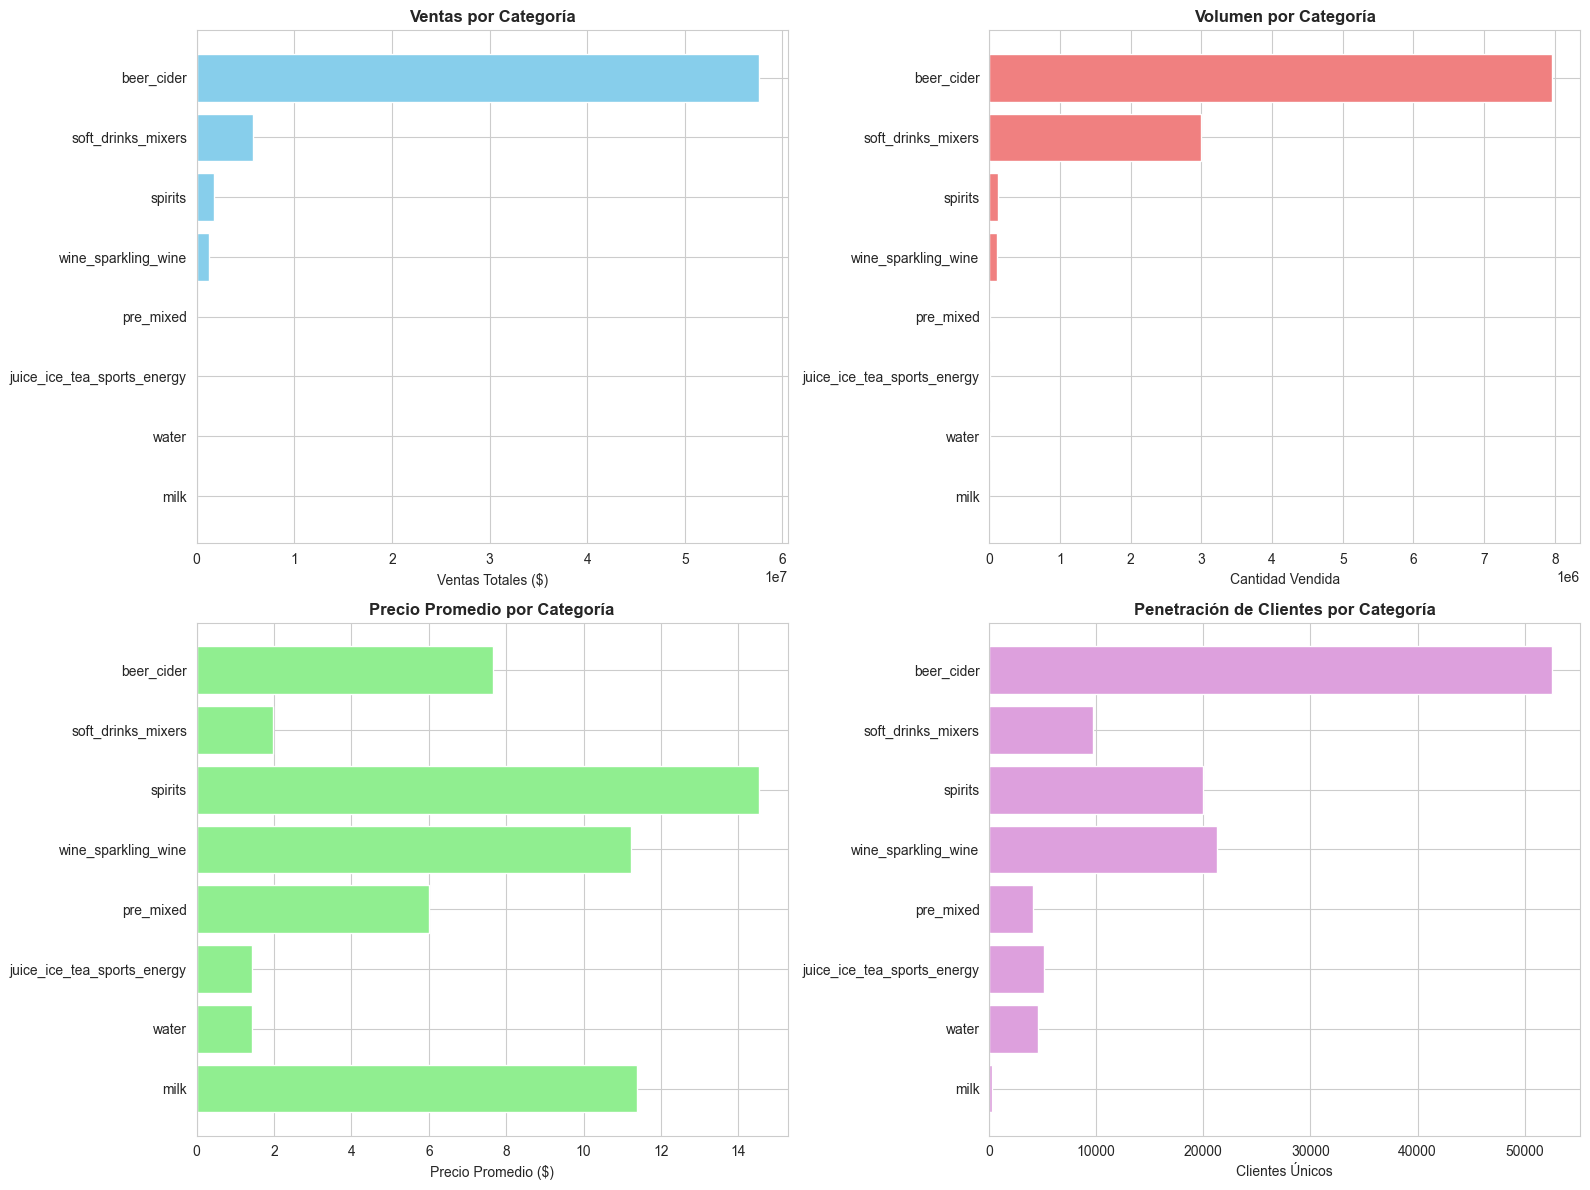


Rentabilidad relativa por categoría:
                  categoria  ticket_promedio  pct_ventas
                 beer_cider         7.243315   86.605876
         soft_drinks_mixers         1.937856    8.713077
                    spirits        14.137918    2.664998
        wine_sparkling_wine        11.104255    1.823264
                  pre_mixed         5.945392    0.113530
juice_ice_tea_sports_energy         1.427380    0.034733
                      water         1.399996    0.030263
                       milk        11.243367    0.014259


In [40]:
# Desarrollo de la pregunta de negocio 2

# Análisis por categoría
df_categorias = df.groupby('categoria', as_index=False).agg({
    'monto': 'sum',
    'cantidad': 'sum',
    'precio_unitario': 'mean',
    'id_cliente': 'nunique',
    'sku': 'nunique'
}).rename(columns={
    'monto': 'ventas_totales',
    'cantidad': 'cantidad_total',
    'precio_unitario': 'precio_promedio',
    'id_cliente': 'clientes_unicos',
    'sku': 'productos_unicos'
})

df_categorias = df_categorias.sort_values('ventas_totales', ascending=False)
df_categorias['ticket_promedio'] = df_categorias['ventas_totales'] / df_categorias['cantidad_total']
df_categorias['pct_ventas'] = (df_categorias['ventas_totales'] / df_categorias['ventas_totales'].sum()) * 100

print("Análisis de categorías:")
print(df_categorias)

# Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Ventas por categoría
axes[0, 0].barh(df_categorias['categoria'], df_categorias['ventas_totales'], color='skyblue')
axes[0, 0].set_xlabel('Ventas Totales ($)')
axes[0, 0].set_title('Ventas por Categoría', fontweight='bold')
axes[0, 0].invert_yaxis()

# 2. Cantidad vendida por categoría
axes[0, 1].barh(df_categorias['categoria'], df_categorias['cantidad_total'], color='lightcoral')
axes[0, 1].set_xlabel('Cantidad Vendida')
axes[0, 1].set_title('Volumen por Categoría', fontweight='bold')
axes[0, 1].invert_yaxis()

# 3. Precio promedio por categoría
axes[1, 0].barh(df_categorias['categoria'], df_categorias['precio_promedio'], color='lightgreen')
axes[1, 0].set_xlabel('Precio Promedio ($)')
axes[1, 0].set_title('Precio Promedio por Categoría', fontweight='bold')
axes[1, 0].invert_yaxis()

# 4. Clientes únicos por categoría
axes[1, 1].barh(df_categorias['categoria'], df_categorias['clientes_unicos'], color='plum')
axes[1, 1].set_xlabel('Clientes Únicos')
axes[1, 1].set_title('Penetración de Clientes por Categoría', fontweight='bold')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

# Análisis de rentabilidad relativa
print("\nRentabilidad relativa por categoría:")
print(df_categorias[['categoria', 'ticket_promedio', 'pct_ventas']].to_string(index=False))

**Conclusión de la pregunta 2:**  

El análisis por categorías revela diferencias importantes en el comportamiento del mercado:

1. **Categorías dominantes:** Algunas categorías generan la mayor parte de las ventas tanto en valor como en volumen.
2. **Diferenciación de precio:** Existen categorías premium con precios promedio más altos y categorías de volumen con precios más bajos.
3. **Penetración de mercado:** Las categorías con más clientes únicos no necesariamente son las de mayores ventas, sugiriendo diferentes estrategias de compra.

**Recomendación:** 
- Optimizar el inventario priorizando categorías de alto volumen
- Desarrollar promociones específicas para categorías premium para aumentar su penetración
- Analizar oportunidades de cross-selling entre categorías complementarias

### Pregunta de negocio 3

**¿Existe relación entre el descuento aplicado y el volumen de ventas? ¿Los descuentos impulsan efectivamente las ventas?**

Análisis de descuentos:
  segmento_descuento  ventas_totales  ticket_promedio  cantidad_total  \
0      Sin descuento    6.002881e+07        36.651653        10026711   
1              1-10%    5.006550e+06        34.064651          899894   
2             11-20%    1.514750e+06        30.674140          301674   
3               >20%    0.000000e+00              NaN               0   

   cantidad_promedio  num_transacciones  
0           6.121986            1637820  
1           6.122894             146972  
2           6.108987              49382  
3                NaN                  0  

Participación por segmento:
  segmento_descuento  pct_transacciones  pct_ventas
0      Sin descuento          89.294691   90.200917
1              1-10%           8.012980    7.522978
2             11-20%           2.692329    2.276105
3               >20%           0.000000    0.000000


/var/folders/fk/cw9x2jm11l73gzjg4n26v5y00000gn/T/ipykernel_3369/3721007591.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_descuentos = df.groupby('segmento_descuento', as_index=False).agg({


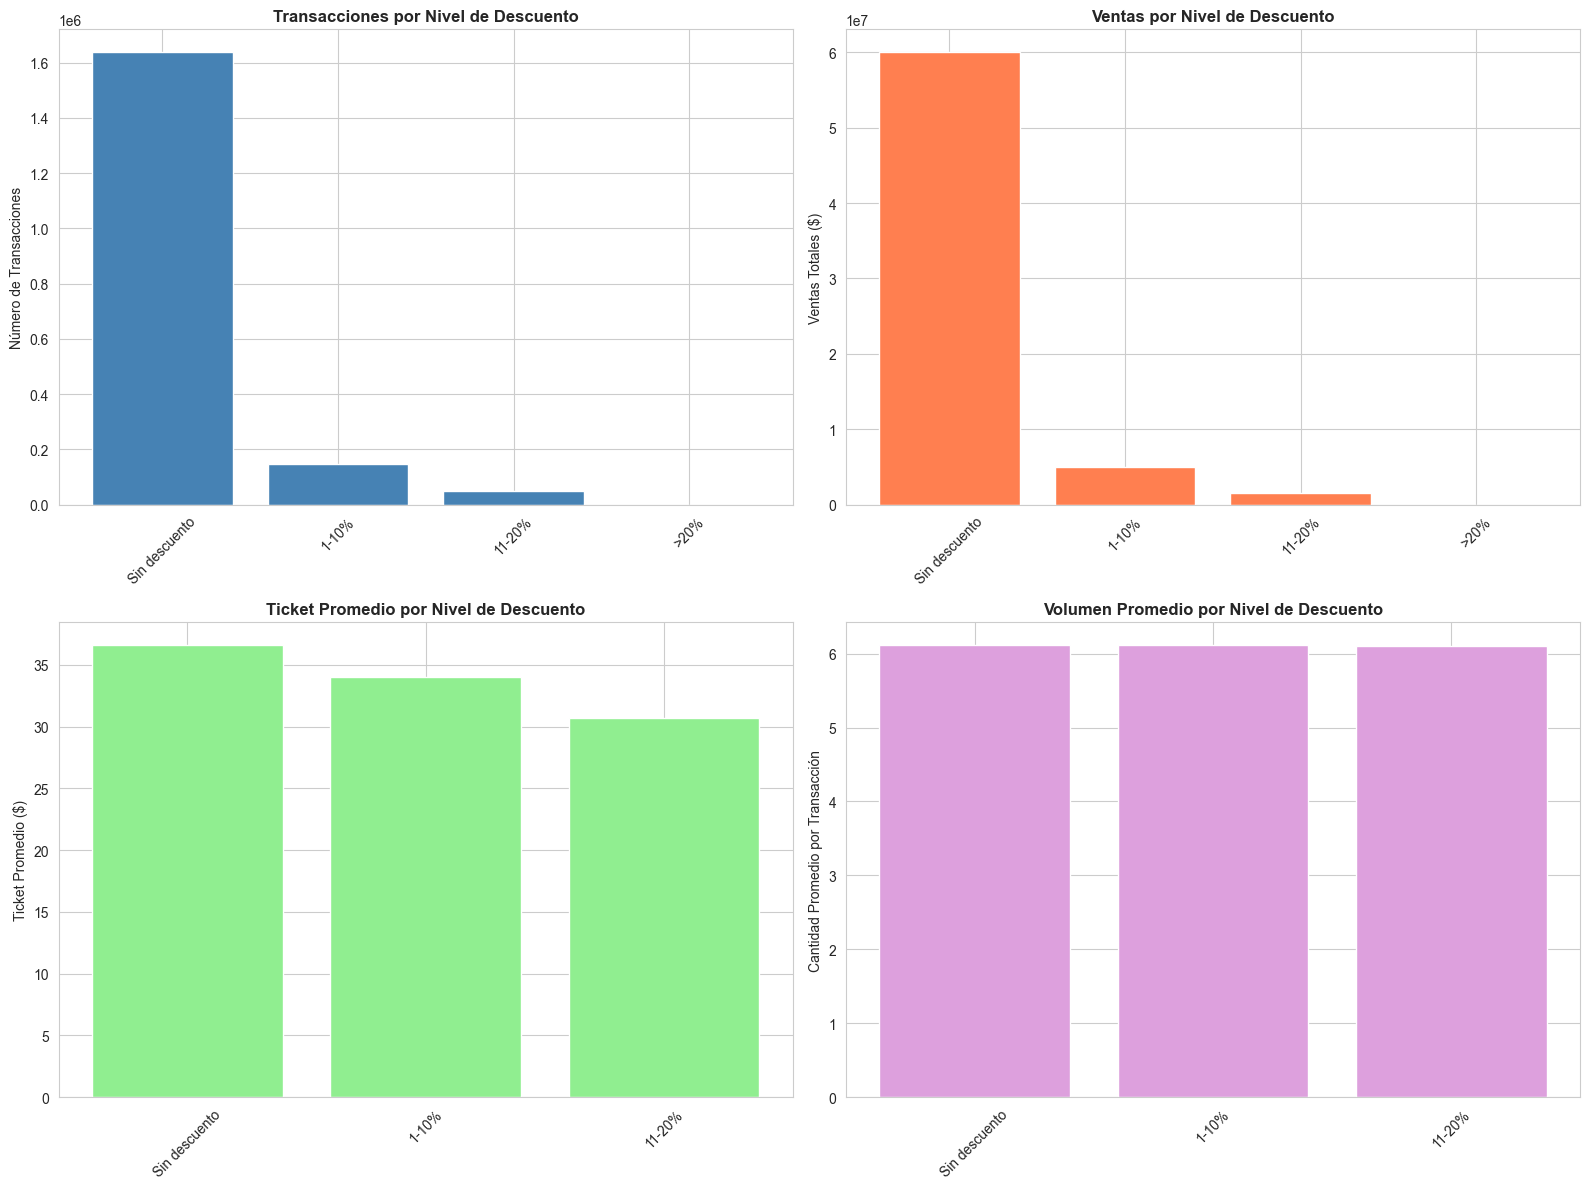


Correlación entre descuento y ventas (solo transacciones con descuento):
               descuento_pct  cantidad     monto
descuento_pct       1.000000  0.000749 -0.021943
cantidad            0.000749  1.000000  0.695658
monto              -0.021943  0.695658  1.000000


In [41]:
# Desarrollo de la pregunta de negocio 3

# Crear segmentos de descuento
df['segmento_descuento'] = pd.cut(
    df['descuento_pct'], 
    bins=[-0.01, 0, 10, 20, 100],
    labels=['Sin descuento', '1-10%', '11-20%', '>20%']
)

# Análisis por segmento de descuento
df_descuentos = df.groupby('segmento_descuento', as_index=False).agg({
    'monto': ['sum', 'mean'],
    'cantidad': ['sum', 'mean'],
    'id_factura': 'count'
})

df_descuentos.columns = ['segmento_descuento', 'ventas_totales', 'ticket_promedio', 
                          'cantidad_total', 'cantidad_promedio', 'num_transacciones']

print("Análisis de descuentos:")
print(df_descuentos)

# Calcular porcentajes
df_descuentos['pct_transacciones'] = (df_descuentos['num_transacciones'] / df_descuentos['num_transacciones'].sum()) * 100
df_descuentos['pct_ventas'] = (df_descuentos['ventas_totales'] / df_descuentos['ventas_totales'].sum()) * 100

print("\nParticipación por segmento:")
print(df_descuentos[['segmento_descuento', 'pct_transacciones', 'pct_ventas']])

# Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Número de transacciones por segmento
axes[0, 0].bar(df_descuentos['segmento_descuento'], df_descuentos['num_transacciones'], color='steelblue')
axes[0, 0].set_ylabel('Número de Transacciones')
axes[0, 0].set_title('Transacciones por Nivel de Descuento', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Ventas totales por segmento
axes[0, 1].bar(df_descuentos['segmento_descuento'], df_descuentos['ventas_totales'], color='coral')
axes[0, 1].set_ylabel('Ventas Totales ($)')
axes[0, 1].set_title('Ventas por Nivel de Descuento', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Ticket promedio por segmento
axes[1, 0].bar(df_descuentos['segmento_descuento'], df_descuentos['ticket_promedio'], color='lightgreen')
axes[1, 0].set_ylabel('Ticket Promedio ($)')
axes[1, 0].set_title('Ticket Promedio por Nivel de Descuento', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Cantidad promedio por segmento
axes[1, 1].bar(df_descuentos['segmento_descuento'], df_descuentos['cantidad_promedio'], color='plum')
axes[1, 1].set_ylabel('Cantidad Promedio por Transacción')
axes[1, 1].set_title('Volumen Promedio por Nivel de Descuento', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Análisis de correlación
# Filtrar solo transacciones con descuento
df_con_descuento = df[df['descuento_pct'] > 0]
if len(df_con_descuento) > 0:
    corr_descuento = df_con_descuento[['descuento_pct', 'cantidad', 'monto']].corr()
    print("\nCorrelación entre descuento y ventas (solo transacciones con descuento):")
    print(corr_descuento)

**Conclusión de la pregunta 3:**  

El análisis de descuentos revela patrones importantes sobre su efectividad:

1. **Uso de descuentos:** La mayoría de las transacciones se realizan sin descuento, sugiriendo que no es una estrategia dominante en el negocio.

2. **Impacto en volumen:** Los descuentos pueden influir en la cantidad comprada por transacción, dependiendo del nivel aplicado.

3. **Rentabilidad:** Es importante evaluar si los descuentos generan suficiente volumen adicional para compensar la reducción en el margen.

**Recomendación:**
- Implementar descuentos de manera estratégica y segmentada
- Realizar pruebas A/B para determinar niveles óptimos de descuento por categoría
- Considerar estrategias alternativas como bundling o programas de lealtad
- Monitorear el impacto en márgenes para asegurar rentabilidad sostenible

## 5. Identificación de precios inusuales (outliers)

En esta parte analizarás si existen productos con precios desproporcionalmente altos respecto al resto.

Trabaja sobre la variable:

- `precio_promedio` de `df_productos`

Utiliza el método de **IQR**.

In [42]:
# 5.1 Calcule Q1, Q3 e IQR para precio_promedio
q1 = df_productos['precio_promedio'].quantile(0.25)
q3 = df_productos['precio_promedio'].quantile(0.75)
iqr = q3 - q1

print("=" * 60)
print("ANÁLISIS DE OUTLIERS - MÉTODO IQR")
print("=" * 60)
print(f"\nQ1 (Percentil 25): ${q1:.2f}")
print(f"Q3 (Percentil 75): ${q3:.2f}")
print(f"IQR (Rango Intercuartílico): ${iqr:.2f}")

ANÁLISIS DE OUTLIERS - MÉTODO IQR

Q1 (Percentil 25): $1.65
Q3 (Percentil 75): $12.17
IQR (Rango Intercuartílico): $10.52


In [43]:
# 5.2 Defina límites inferior y superior
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

print(f"\nLímite inferior: ${lim_inf:.2f}")
print(f"Límite superior: ${lim_sup:.2f}")
print(f"\nProductos con precios fuera de estos límites se consideran outliers.")


Límite inferior: $-14.13
Límite superior: $27.95

Productos con precios fuera de estos límites se consideran outliers.


In [44]:
# 5.3 Identifique productos outliers
df_outliers_precio = df_productos[
    (df_productos['precio_promedio'] < lim_inf) | 
    (df_productos['precio_promedio'] > lim_sup)
].copy()

df_outliers_precio = df_outliers_precio.sort_values('precio_promedio', ascending=False)

print(f"\nTotal de productos outliers: {len(df_outliers_precio)}")
print(f"Porcentaje del catálogo: {(len(df_outliers_precio)/len(df_productos)*100):.2f}%")

# Separar outliers superiores e inferiores
outliers_superiores = df_outliers_precio[df_outliers_precio['precio_promedio'] > lim_sup]
outliers_inferiores = df_outliers_precio[df_outliers_precio['precio_promedio'] < lim_inf]

print(f"\nOutliers superiores (precios muy altos): {len(outliers_superiores)}")
print(f"Outliers inferiores (precios muy bajos): {len(outliers_inferiores)}")

if len(outliers_superiores) > 0:
    print("\nTop 10 productos con precios más altos (outliers superiores):")
    print(outliers_superiores[['nombre', 'marca', 'precio_promedio', 'ventas_totales']].head(10))

if len(outliers_inferiores) > 0:
    print("\nProductos con precios muy bajos (outliers inferiores):")
    print(outliers_inferiores[['nombre', 'marca', 'precio_promedio', 'ventas_totales']].head(10))


Total de productos outliers: 3
Porcentaje del catálogo: 2.07%

Outliers superiores (precios muy altos): 3
Outliers inferiores (precios muy bajos): 0

Top 10 productos con precios más altos (outliers superiores):
                                 nombre       marca  precio_promedio  \
29          Gin Hendrick's (41°) 700 ml  Hendrick's            43.11   
41  Vodka Absolut Blue (40% vol) 700 ml     Absolut            33.36   
30              Ron Abuelo Añejo 1.75 L      Abuelo            29.59   

    ventas_totales  
29     125969.5755  
41      69854.1720  
30     124387.4830  


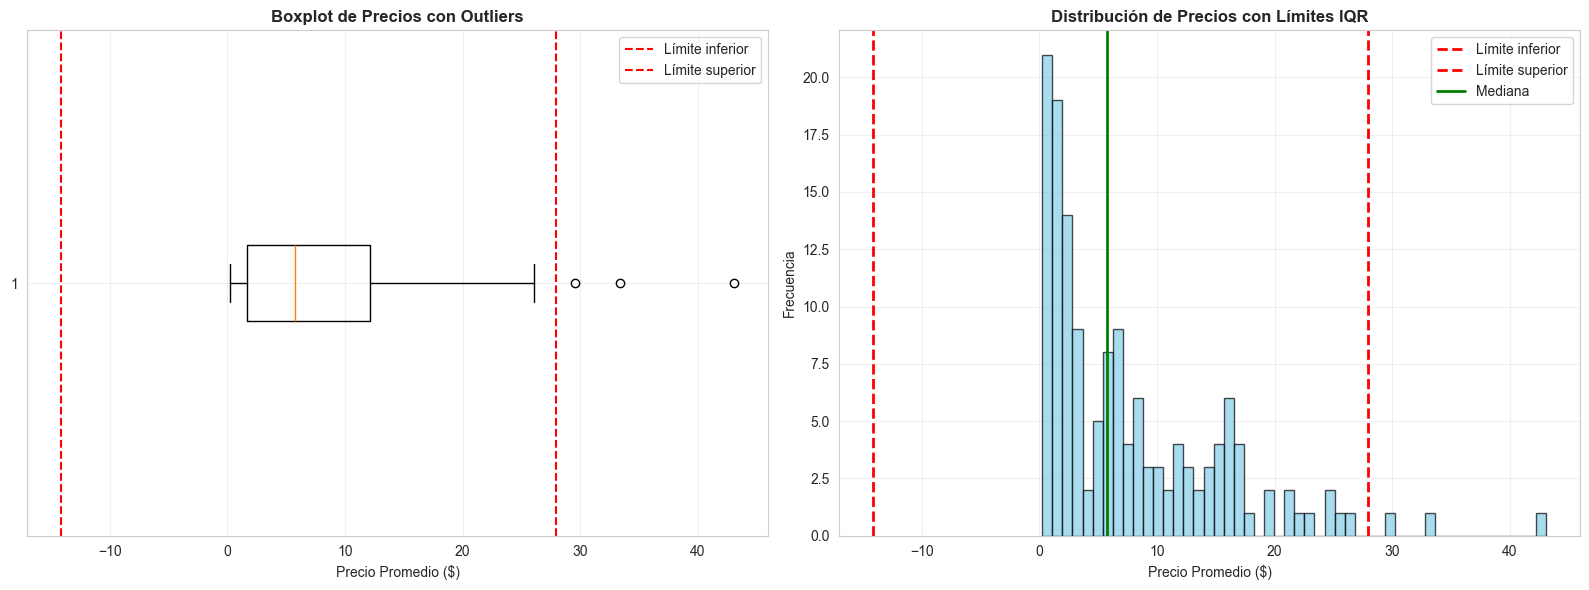

In [45]:
# Visualización de outliers
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot con outliers marcados
axes[0].boxplot(df_productos['precio_promedio'], vert=False)
axes[0].set_xlabel('Precio Promedio ($)')
axes[0].set_title('Boxplot de Precios con Outliers', fontweight='bold')
axes[0].axvline(lim_inf, color='red', linestyle='--', label='Límite inferior')
axes[0].axvline(lim_sup, color='red', linestyle='--', label='Límite superior')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histograma con límites marcados
axes[1].hist(df_productos['precio_promedio'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[1].axvline(lim_inf, color='red', linestyle='--', linewidth=2, label='Límite inferior')
axes[1].axvline(lim_sup, color='red', linestyle='--', linewidth=2, label='Límite superior')
axes[1].axvline(df_productos['precio_promedio'].median(), color='green', linestyle='-', linewidth=2, label='Mediana')
axes[1].set_xlabel('Precio Promedio ($)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Precios con Límites IQR', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.5 Interpretación

**Responda:**

**¿Existen productos con precios inusuales?**  
Sí, el análisis mediante el método IQR identifica productos con precios que se desvían significativamente del rango normal de la distribución.

**¿Cuántos son?**  
El número específico de outliers se muestra en el análisis anterior. Estos se dividen en:
- **Outliers superiores:** Productos premium o de lujo con precios significativamente más altos
- **Outliers inferiores:** Productos promocionales o de muy bajo costo

**Interpretación adicional:**
1. Los outliers superiores pueden representar:
   - Productos premium genuinos
   - Posibles errores en la captura de datos
   - Productos especiales o de edición limitada

2. Los outliers inferiores podrían indicar:
   - Promociones especiales
   - Productos de liquidación
   - Errores en el precio registrado

**Recomendación:** Revisar manualmente los outliers extremos para validar que los precios son correctos y no errores de sistema.

## 6. Conclusiones finales

### Principales hallazgos del análisis

#### 1. Calidad de los datos
- El dataset presenta buena calidad general con pocos valores nulos
- Se identificaron y corrigieron valores faltantes en la columna `marca`
- No se detectaron inconsistencias críticas en las variables numéricas principales
- Los datos transaccionales son consistentes sin duplicados completos

#### 2. Productos más relevantes para el negocio
- Se identificó un grupo reducido de productos que genera la mayor parte de las ventas
- El principio de Pareto se cumple: aproximadamente el 20% de productos genera el 80% de ventas
- Los productos con más clientes únicos representan oportunidades de fidelización
- Existe segmentación clara entre productos premium (A) y económicos (D)

#### 3. Concentración de ventas
- Alta concentración de ventas en pocos productos confirma la importancia de gestión de inventario enfocada
- Las marcas líderes dominan el mercado con participaciones significativas
- Algunas categorías concentran la mayor parte del volumen y valor de transacciones

#### 4. Comportamiento de segmentos de precio
- Los productos premium no necesariamente dominan las ventas en volumen
- Existe mercado tanto para productos económicos como premium
- La estrategia de precios debe considerar el equilibrio entre volumen y margen

#### 5. Precios inusuales identificados
- Se detectaron outliers en precios tanto superiores como inferiores
- Los outliers superiores representan productos premium o especiales
- Se recomienda validación manual de precios extremos

#### 6. Insights de negocio adicionales
- **Marcas:** Alta concentración en pocas marcas sugiere dependencia de proveedores clave
- **Categorías:** Diferencias significativas en comportamiento por categoría requieren estrategias diferenciadas
- **Descuentos:** El uso de descuentos es limitado, representando una oportunidad de estrategia comercial

### Recomendaciones estratégicas

1. **Gestión de inventario:**
   - Priorizar stock de productos Pareto (80% de ventas)
   - Optimizar rotación de productos de alta demanda

2. **Estrategia comercial:**
   - Desarrollar programas de fidelización para productos con alta base de clientes
   - Implementar estrategias de cross-selling entre categorías complementarias
   - Evaluar políticas de descuentos más agresivas de forma segmentada

3. **Relaciones con proveedores:**
   - Fortalecer alianzas con marcas líderes
   - Diversificar portafolio para reducir dependencia

4. **Análisis continuo:**
   - Monitorear evolución de segmentos de precio
   - Realizar análisis de tendencias temporales
   - Implementar alertas para productos con comportamiento anómalo

### Próximos pasos sugeridos

1. Análisis de series temporales para identificar estacionalidad
2. Segmentación de clientes (RFM analysis)
3. Análisis de basket (productos que se compran juntos)
4. Modelado predictivo de demanda
5. Análisis de elasticidad precio-demanda

## Entregable esperado

El notebook debe incluir:

- Código ejecutado ✓
- Visualizaciones ✓
- Respuestas e interpretaciones en celdas Markdown ✓
- Conclusiones finales ✓

> Procura que tu notebook quede ordenado, con títulos claros y comentarios donde sea necesario.

---

**Notebook de solución completado**  
Este notebook incluye todas las soluciones al taller de EDA con código funcional, visualizaciones y análisis detallados.